(256, 256)


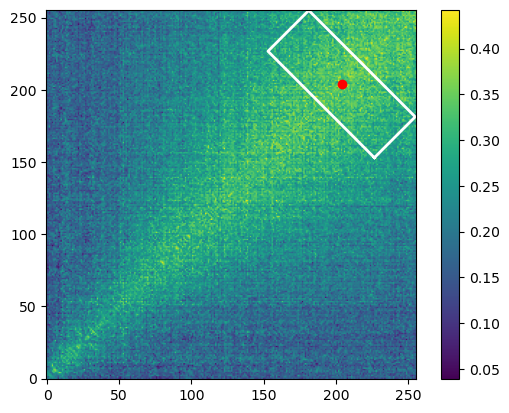

In [93]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
import pickle
from reshape_funs import diagonal_resample_square
matfile = "D2_A_170C_B1_batch001_q009_phi001_twotimeresult.mat"
M = scipy.io.loadmat(matfile)["C"]
Mp = resize(M,(256,256),anti_aliasing=True)
print(np.shape(Mp))
im = plt.imshow(Mp, origin='lower')
plt.colorbar(im)
Mrot, xp, yp, x0, y0, xpmax, corners, boundary = diagonal_resample_square(
    Mp, frac=0.80, half_size=20, dx=1.0
)
plt.plot(boundary[:, 0], boundary[:, 1], 'w-', linewidth=2)
plt.plot(x0, y0, 'ro')
plt.show()

[-1.  0.  1.  2.]
0.34041274


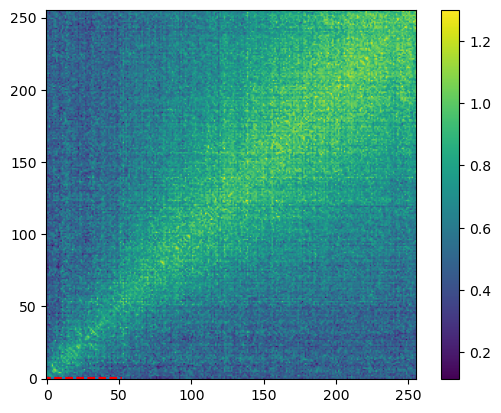

In [95]:
yp = np.average(Mrot,0)
nx = np.shape(Mrot)[1]
ny = np.shape(Mrot)[0]
xp = np.arange(nx)-nx/2
plt.plot(xp,yp)
print(xp[int(nx/2+1)-2:int(nx/2+1)+2])
ymean = np.average(yp[int(nx/2+1)-2:int(nx/2+1)+2]) 
print(ymean)
plt.plot(xp,xp*0+ymean,'--r')
Mout = Mp/ymean
im = plt.imshow(Mout, origin='lower')
plt.colorbar(im)
np.save("Mp.npy",Mp)